In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc 
from sklearn.metrics import f1_score
import json
from pathlib import Path
from datetime import datetime

import sys
import os

sys.path.append(os.path.abspath(os.path.join('..')))

from src.load_data_gait import *
from src.plot_data_gait import *
from src.train_LSTMGait import train_model, predict_trial

In [3]:
base_path = '../datasets/GAIT_signals/dataset/data'

In [4]:
lr = 0.001
dropout = 0.5
cnn_channels = [64, 128, 128]
kernel_size = 7
batch_size = 128
window_size = 200
stride = 50

# LB Only

In [5]:
X, y, subjects = load_dataset_gait(base_path, process="free_raw", sensors=['LB'], window_size=window_size, stride=stride)
X = X.astype(np.float32)
y = y.astype(np.int64)

model_name = "cnn_bilstm_LB_only"

ckpt_path = f"../checkpoints/best_model_{model_name}"

In [ ]:
trained_model, best_val_f1, test_f1, df_val_f1, df_test_f1 = train_model(
    X, y, subjects, model_name="cnnbilstm", norm="window", 
    epochs=200, lr=lr, patience=20, dropout=dropout, 
    cnn_channels=cnn_channels, kernel_size=kernel_size, 
    batch_size=batch_size, out_dir=ckpt_path, plot=True)


Subject split  →  train+val: 208 subjects  |  test: 52 subjects
Window split   →  train+val: 59352  |  test: 17108
               →  train: 166 subjects (46063 windows)  |  val: 42 subjects (13289 windows)


Early stopping in epoch 72. Best F1: 0.8627

Val F1: 0.8627  |  Test F1: 0.8727
Checkpoint saved → ../checkpoints/best_model_cnn_bilstm_LB_only/model.pt


In [7]:
print(f"Validation F1 score: {best_val_f1:.4f}")
print(f"Test F1 score: {test_f1:.4f}")

Validation F1 score: 0.8627
Test F1 score: 0.8727


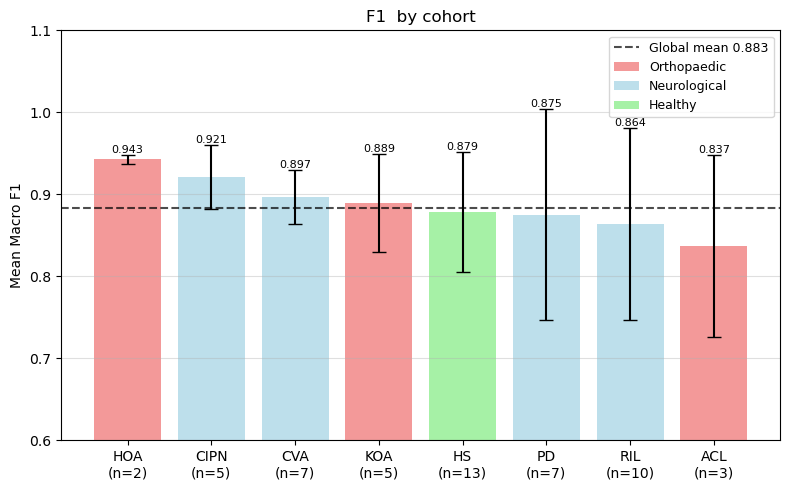

In [8]:
diseases = []
for subj in df_test_f1['subject']:
  diseases.append(subj.split("_")[0])

df_test_f1['Disease'] = diseases

stats = plot_f1_by_cohort(df_test_f1, title="F1  by cohort")

# LB + Right foot

In [9]:
X, y, subjects = load_dataset_gait(base_path, process="free_raw", sensors=['LB', 'RF'], window_size=window_size, stride=stride)
X = X.astype(np.float32)
y = y.astype(np.int64)

model_name = "cnn_bilstm_LB_RF"
ckpt_path = f"../checkpoints/best_model_{model_name}"

In [ ]:
trained_model, best_val_f1, test_f1, df_val_f1, df_test_f1 = train_model(
    X, y, subjects, model_name="cnnbilstm", norm="window", 
    epochs=200, lr=lr, patience=20, dropout=dropout, 
    cnn_channels=cnn_channels, kernel_size=kernel_size, 
    batch_size=batch_size, out_dir=ckpt_path, plot=True)


Subject split  →  train+val: 208 subjects  |  test: 52 subjects
Window split   →  train+val: 59193  |  test: 17106
               →  train: 166 subjects (45943 windows)  |  val: 42 subjects (13250 windows)


Early stopping in epoch 63. Best F1: 0.8932

Val F1: 0.8932  |  Test F1: 0.9247
Checkpoint saved → ../checkpoints/best_model_cnn_bilstm_LB_RF/model.pt


In [11]:
print(f"Validation F1 score: {best_val_f1:.4f}")
print(f"Test F1 score: {test_f1:.4f}")

Validation F1 score: 0.8932
Test F1 score: 0.9247


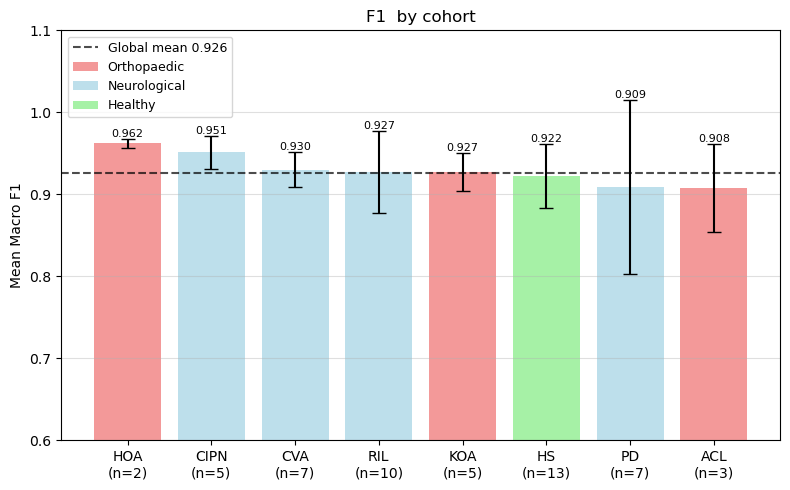

In [12]:
diseases = []
for subj in df_test_f1['subject']:
  diseases.append(subj.split("_")[0])

df_test_f1['Disease'] = diseases

stats = plot_f1_by_cohort(df_test_f1, title="F1  by cohort")

# LB + Left foot

In [13]:
X, y, subjects = load_dataset_gait(base_path, process="free_raw", sensors=['LB', 'LF'], window_size=window_size, stride=stride)
X = X.astype(np.float32)
y = y.astype(np.int64)

model_name = "cnn_bilstm_LB_LF"
ckpt_path = f"../checkpoints/best_model_{model_name}"

In [ ]:
trained_model, best_val_f1, test_f1, df_val_f1, df_test_f1 = train_model(
    X, y, subjects, model_name="cnnbilstm", norm="window", 
    epochs=200, lr=lr, patience=20, dropout=dropout, 
    cnn_channels=cnn_channels, kernel_size=kernel_size, 
    batch_size=batch_size, out_dir=ckpt_path, plot=True)


Subject split  →  train+val: 208 subjects  |  test: 52 subjects
Window split   →  train+val: 59336  |  test: 17107
               →  train: 166 subjects (46048 windows)  |  val: 42 subjects (13288 windows)


Early stopping in epoch 44. Best F1: 0.9011

Val F1: 0.9011  |  Test F1: 0.9235
Checkpoint saved → ../checkpoints/best_model_cnn_bilstm_LB_LF/model.pt


In [15]:
print(f"Validation F1 score: {best_val_f1:.4f}")
print(f"Test F1 score: {test_f1:.4f}")

Validation F1 score: 0.9011
Test F1 score: 0.9235


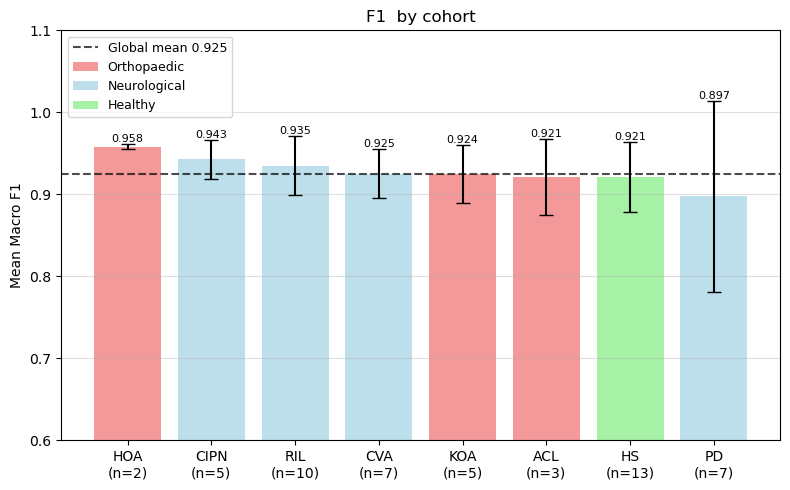

In [16]:
diseases = []
for subj in df_test_f1['subject']:
  diseases.append(subj.split("_")[0])

df_test_f1['Disease'] = diseases

stats = plot_f1_by_cohort(df_test_f1, title="F1  by cohort")

# LB + Affected foot

In [17]:
X, y, subjects = load_dataset_gait(base_path, process="free_raw", sensors=['LB', 'affected'], window_size=window_size, stride=stride)
X = X.astype(np.float32)
y = y.astype(np.int64)

model_name = "cnn_bilstm_LB_affected"
ckpt_path = f"../checkpoints/best_model_{model_name}"

In [ ]:
trained_model, best_val_f1, test_f1, df_val_f1, df_test_f1 = train_model(
    X, y, subjects, model_name="cnnbilstm", norm="window", 
    epochs=200, lr=lr, patience=20, dropout=dropout, 
    cnn_channels=cnn_channels, kernel_size=kernel_size, 
    batch_size=batch_size, out_dir=ckpt_path, plot=True)


Subject split  →  train+val: 208 subjects  |  test: 52 subjects
Window split   →  train+val: 59335  |  test: 17107
               →  train: 166 subjects (46048 windows)  |  val: 42 subjects (13287 windows)


Early stopping in epoch 63. Best F1: 0.8836

Val F1: 0.8836  |  Test F1: 0.9129
Checkpoint saved → ../checkpoints/best_model_cnn_bilstm_LB_affected/model.pt


In [19]:
print(f"Validation F1 score: {best_val_f1:.4f}")
print(f"Test F1 score: {test_f1:.4f}")

Validation F1 score: 0.8836
Test F1 score: 0.9129


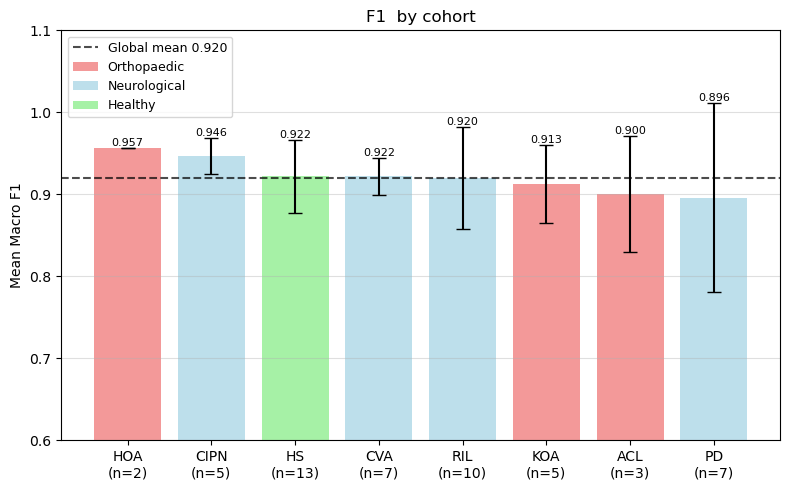

In [20]:
diseases = []
for subj in df_test_f1['subject']:
  diseases.append(subj.split("_")[0])

df_test_f1['Disease'] = diseases

stats = plot_f1_by_cohort(df_test_f1, title="F1  by cohort")

# LB + Non affected foot

In [21]:
X, y, subjects = load_dataset_gait(base_path, process="free_raw", sensors=['LB', 'non_affected'], window_size=window_size, stride=stride)
X = X.astype(np.float32)
y = y.astype(np.int64)

model_name = "cnn_bilstm_LB_non_affected"
ckpt_path = f"../checkpoints/best_model_{model_name}"

In [ ]:
trained_model, best_val_f1, test_f1, df_val_f1, df_test_f1 = train_model(
    X, y, subjects, model_name="cnnbilstm", norm="window", 
    epochs=200, lr=lr, patience=20, dropout=dropout, 
    cnn_channels=cnn_channels, kernel_size=kernel_size, 
    batch_size=batch_size, out_dir=ckpt_path, plot=True)


Subject split  →  train+val: 208 subjects  |  test: 52 subjects
Window split   →  train+val: 59337  |  test: 17106
               →  train: 166 subjects (46050 windows)  |  val: 42 subjects (13287 windows)


Early stopping in epoch 54. Best F1: 0.8886

Val F1: 0.8886  |  Test F1: 0.9113
Checkpoint saved → ../checkpoints/best_model_cnn_bilstm_LB_non_affected/model.pt


In [23]:
print(f"Validation F1 score: {best_val_f1:.4f}")
print(f"Test F1 score: {test_f1:.4f}")

Validation F1 score: 0.8886
Test F1 score: 0.9113


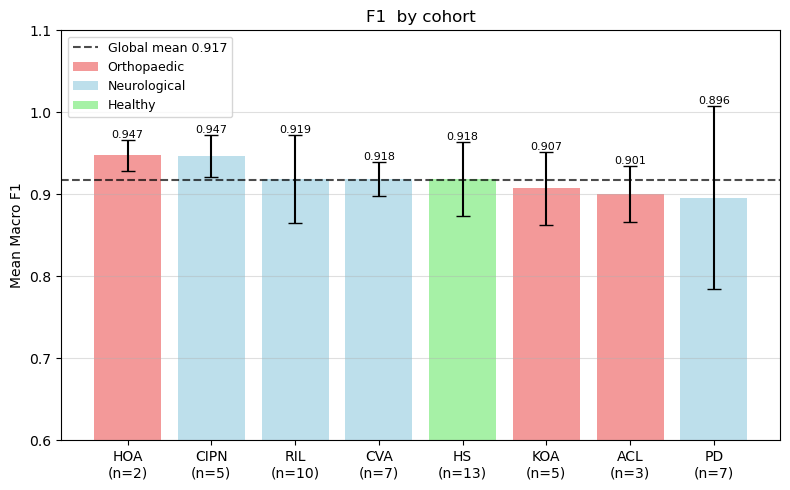

In [24]:
diseases = []
for subj in df_test_f1['subject']:
  diseases.append(subj.split("_")[0])

df_test_f1['Disease'] = diseases

stats = plot_f1_by_cohort(df_test_f1, title="F1  by cohort")

# RF + LF

In [25]:
X, y, subjects = load_dataset_gait(base_path, process="free_raw", sensors=['RF', 'LF'], window_size=window_size, stride=stride)
X = X.astype(np.float32)
y = y.astype(np.int64)

model_name = "cnn_bilstm_RF_LF"
ckpt_path = f"../checkpoints/best_model_{model_name}"

In [ ]:
trained_model, best_val_f1, test_f1, df_val_f1, df_test_f1 = train_model(
    X, y, subjects, model_name="cnnbilstm", norm="window", 
    epochs=200, lr=lr, patience=20, dropout=dropout, 
    cnn_channels=cnn_channels, kernel_size=kernel_size, 
    batch_size=batch_size, out_dir=ckpt_path, plot=True)


Subject split  →  train+val: 208 subjects  |  test: 52 subjects
Window split   →  train+val: 59196  |  test: 17105
               →  train: 166 subjects (45945 windows)  |  val: 42 subjects (13251 windows)


Early stopping in epoch 72. Best F1: 0.9107

Val F1: 0.9107  |  Test F1: 0.9454
Checkpoint saved → ../checkpoints/best_model_cnn_bilstm_RF_LF/model.pt


In [27]:
print(f"Validation F1 score: {best_val_f1:.4f}")
print(f"Test F1 score: {test_f1:.4f}")

Validation F1 score: 0.9107
Test F1 score: 0.9454


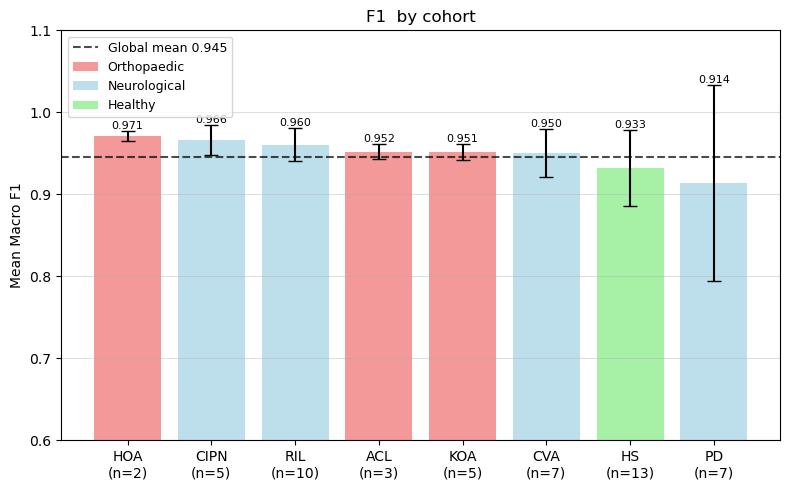

In [28]:
diseases = []
for subj in df_test_f1['subject']:
  diseases.append(subj.split("_")[0])

df_test_f1['Disease'] = diseases

stats = plot_f1_by_cohort(df_test_f1, title="F1  by cohort")

# LB + RF + LF

In [29]:
X, y, subjects = load_dataset_gait(base_path, process="free_raw", sensors=['LB', 'RF', 'LF'], window_size=window_size, stride=stride)
X = X.astype(np.float32)
y = y.astype(np.int64)

model_name = "cnn_bilstm_LB_RF_LF"
ckpt_path = f"../checkpoints/best_model_{model_name}"

In [ ]:
trained_model, best_val_f1, test_f1, df_val_f1, df_test_f1 = train_model(
    X, y, subjects, model_name="cnnbilstm", norm="window", 
    epochs=200, lr=lr, patience=20, dropout=dropout, 
    cnn_channels=cnn_channels, kernel_size=kernel_size, 
    batch_size=batch_size, out_dir=ckpt_path, plot=True)


Subject split  →  train+val: 208 subjects  |  test: 52 subjects
Window split   →  train+val: 59187  |  test: 17105
               →  train: 166 subjects (45937 windows)  |  val: 42 subjects (13250 windows)


Early stopping in epoch 62. Best F1: 0.9143

Val F1: 0.9143  |  Test F1: 0.9459
Checkpoint saved → ../checkpoints/best_model_cnn_bilstm_LB_RF_LF/model.pt


OSError: Cannot save file into a non-existent directory: 'results'

In [31]:
print(f"Validation F1 score: {best_val_f1:.4f}")
print(f"Test F1 score: {test_f1:.4f}")

Validation F1 score: 0.9143
Test F1 score: 0.9459


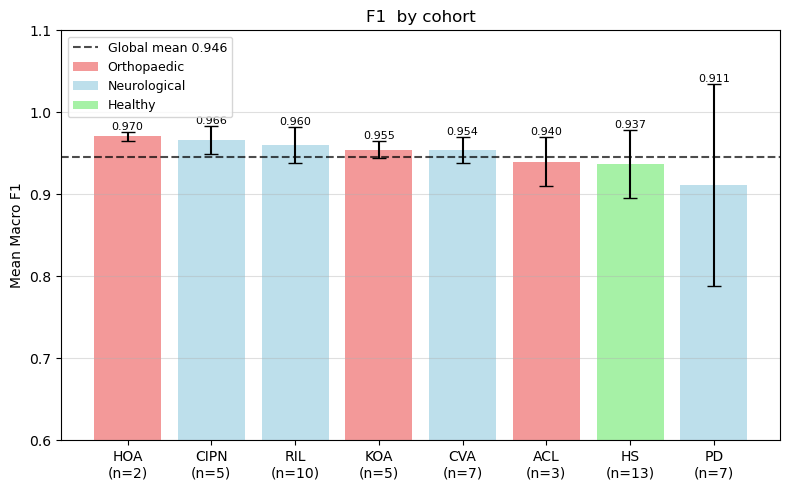

In [32]:
diseases = []
for subj in df_test_f1['subject']:
  diseases.append(subj.split("_")[0])

df_test_f1['Disease'] = diseases

stats = plot_f1_by_cohort(df_test_f1, title="F1  by cohort")

# HE

In [33]:
X, y, subjects = load_dataset_gait(base_path, process="free_raw", sensors=['HE'], window_size=window_size, stride=stride)
X = X.astype(np.float32)
y = y.astype(np.int64)

model_name = "cnn_bilstm_HE"
ckpt_path = f"../checkpoints/best_model_{model_name}"

In [ ]:
trained_model, best_val_f1, test_f1, df_val_f1, df_test_f1 = train_model(
    X, y, subjects, model_name="cnnbilstm", norm="window", 
    epochs=200, lr=lr, patience=20, dropout=dropout, 
    cnn_channels=cnn_channels, kernel_size=kernel_size, 
    batch_size=batch_size, out_dir=ckpt_path, plot=True)


Subject split  →  train+val: 208 subjects  |  test: 52 subjects
Window split   →  train+val: 59364  |  test: 17107
               →  train: 166 subjects (46074 windows)  |  val: 42 subjects (13290 windows)


Early stopping in epoch 51. Best F1: 0.8409

Val F1: 0.8409  |  Test F1: 0.8621
Checkpoint saved → ../checkpoints/best_model_cnn_bilstm_HE/model.pt


In [35]:
print(f"Validation F1 score: {best_val_f1:.4f}")
print(f"Test F1 score: {test_f1:.4f}")

Validation F1 score: 0.8409
Test F1 score: 0.8621


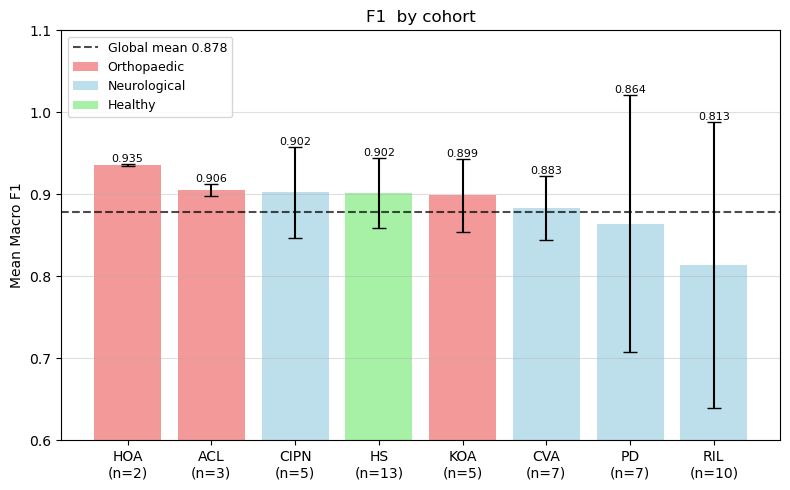

In [36]:
diseases = []
for subj in df_test_f1['subject']:
  diseases.append(subj.split("_")[0])

df_test_f1['Disease'] = diseases

stats = plot_f1_by_cohort(df_test_f1, title="F1  by cohort")

# RF

In [37]:
X, y, subjects = load_dataset_gait(base_path, process="free_raw", sensors=['RF'], window_size=window_size, stride=stride)
X = X.astype(np.float32)
y = y.astype(np.int64)

model_name = "cnn_bilstm_RF"
ckpt_path = f"../checkpoints/best_model_{model_name}"

In [ ]:
trained_model, best_val_f1, test_f1, df_val_f1, df_test_f1 = train_model(
    X, y, subjects, model_name="cnnbilstm", norm="window", 
    epochs=200, lr=lr, patience=20, dropout=dropout, 
    cnn_channels=cnn_channels, kernel_size=kernel_size, 
    batch_size=batch_size, out_dir=ckpt_path, plot=True)


Subject split  →  train+val: 208 subjects  |  test: 52 subjects
Window split   →  train+val: 59202  |  test: 17106
               →  train: 166 subjects (45951 windows)  |  val: 42 subjects (13251 windows)


Early stopping in epoch 76. Best F1: 0.8704

Val F1: 0.8704  |  Test F1: 0.8936
Checkpoint saved → ../checkpoints/best_model_cnn_bilstm_RF/model.pt


In [39]:
print(f"Validation F1 score: {best_val_f1:.4f}")
print(f"Test F1 score: {test_f1:.4f}")

Validation F1 score: 0.8704
Test F1 score: 0.8936


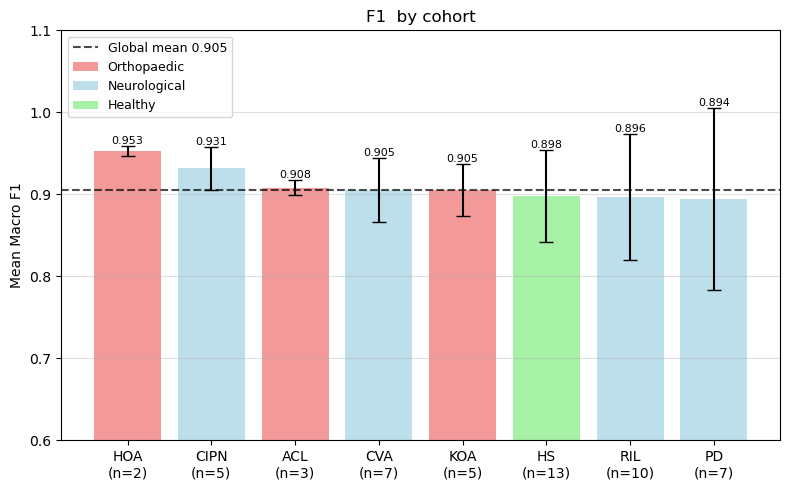

In [40]:
diseases = []
for subj in df_test_f1['subject']:
  diseases.append(subj.split("_")[0])

df_test_f1['Disease'] = diseases

stats = plot_f1_by_cohort(df_test_f1, title="F1  by cohort")

# LF

In [41]:
X, y, subjects = load_dataset_gait(base_path, process="free_raw", sensors=['LF'], window_size=window_size, stride=stride)
X = X.astype(np.float32)
y = y.astype(np.int64)

model_name = "cnn_bilstm_LF"
ckpt_path = f"../checkpoints/best_model_{model_name}"

In [ ]:
trained_model, best_val_f1, test_f1, df_val_f1, df_test_f1 = train_model(
    X, y, subjects, model_name="cnnbilstm", norm="window", 
    epochs=200, lr=lr, patience=20, dropout=dropout, 
    cnn_channels=cnn_channels, kernel_size=kernel_size, 
    batch_size=batch_size, out_dir=ckpt_path, plot=True)


Subject split  →  train+val: 208 subjects  |  test: 52 subjects
Window split   →  train+val: 59358  |  test: 17107
               →  train: 166 subjects (46068 windows)  |  val: 42 subjects (13290 windows)


Early stopping in epoch 41. Best F1: 0.8866

Val F1: 0.8866  |  Test F1: 0.9002
Checkpoint saved → ../checkpoints/best_model_cnn_bilstm_LF/model.pt


In [43]:
print(f"Validation F1 score: {best_val_f1:.4f}")
print(f"Test F1 score: {test_f1:.4f}")

Validation F1 score: 0.8866
Test F1 score: 0.9002


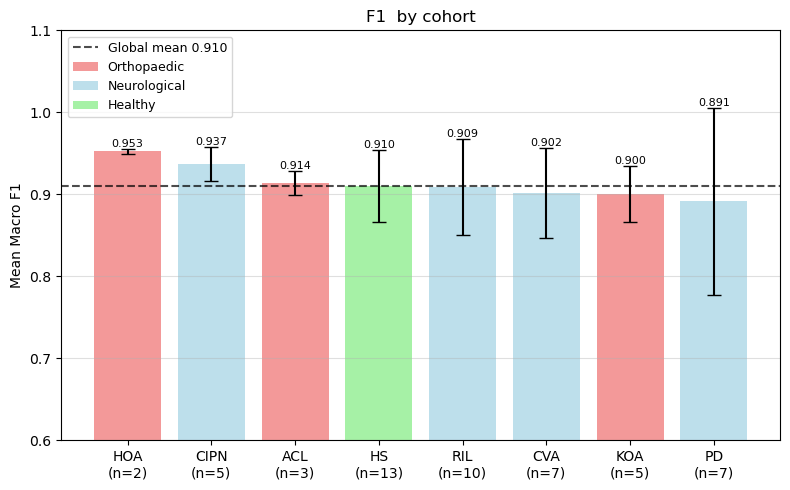

In [44]:
diseases = []
for subj in df_test_f1['subject']:
  diseases.append(subj.split("_")[0])

df_test_f1['Disease'] = diseases

stats = plot_f1_by_cohort(df_test_f1, title="F1  by cohort")

# All sensors

In [ ]:
X, y, subjects = load_dataset_gait(base_path, process="free_raw", window_size=window_size, stride=stride)
X = X.astype(np.float32)
y = y.astype(np.int64)

model_name = "cnn_bilstm_all_sensors"
ckpt_path = f"../checkpoints/best_model_{model_name}"

: 

In [ ]:
trained_model, best_val_f1, test_f1, df_val_f1, df_test_f1 = train_model(
    X, y, subjects, model_name="cnnbilstm", norm="window", 
    epochs=200, lr=lr, patience=20, dropout=dropout, 
    cnn_channels=cnn_channels, kernel_size=kernel_size, 
    batch_size=batch_size, out_dir=ckpt_path, plot=True)


Subject split  →  train+val: 208 subjects  |  test: 52 subjects
Window split   →  train+val: 59183  |  test: 17104
               →  train: 166 subjects (45933 windows)  |  val: 42 subjects (13250 windows)


Training:   6%|▋         | 13/200 [11:19<2:43:08, 52.34s/it, Val F1=0.913, LR=0.001000]

In [ ]:
print(f"Validation F1 score: {best_val_f1:.4f}")
print(f"Test F1 score: {test_f1:.4f}")

Validation F1 score: 0.9164
Test F1 score: 0.9463


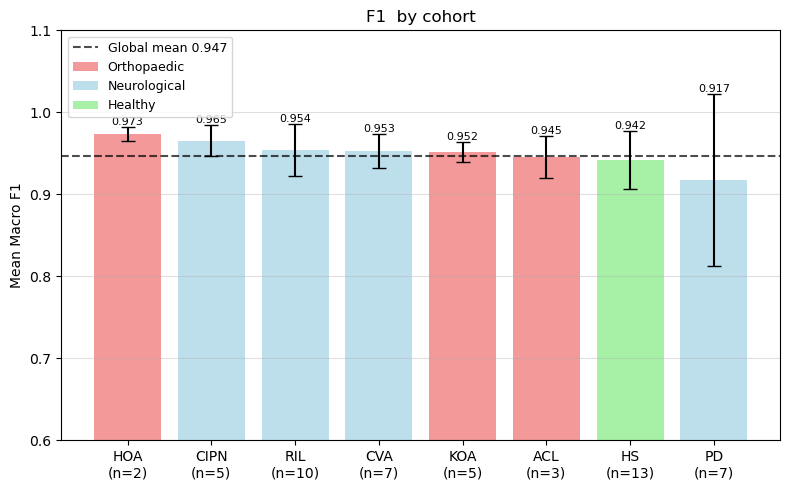

In [ ]:
diseases = []
for subj in df_test_f1['subject']:
  diseases.append(subj.split("_")[0])

df_test_f1['Disease'] = diseases

stats = plot_f1_by_cohort(df_test_f1, title="F1  by cohort")

# All sensors processed

In [ ]:
X, y, subjects = load_dataset_gait(base_path, process="preprocessed", window_size=window_size, stride=stride)
X = X.astype(np.float32)
y = y.astype(np.int64)

model_name = "cnn_bilstm_all_sensors_processed"
ckpt_path = f"../checkpoints/best_model_{model_name}"

In [ ]:
trained_model, best_val_f1, test_f1, df_val_f1, df_test_f1 = train_model(
    X, y, subjects, model_name="cnnbilstm", norm="window", 
    epochs=200, lr=lr, patience=20, dropout=dropout, 
    cnn_channels=cnn_channels, kernel_size=kernel_size, 
    batch_size=batch_size, out_dir=ckpt_path, plot=True)


Subject split  →  train+val: 208 subjects  |  test: 52 subjects
Window split   →  train+val: 59459  |  test: 17121
               →  train: 166 subjects (46136 windows)  |  val: 42 subjects (13323 windows)


Early stopping in epoch 81. Best F1: 0.9663

Val F1: 0.9663  |  Test F1: 0.9626
Checkpoint saved → ../checkpoints/best_model_cnn_bilstm_all_sensors_processed/model.pt


In [ ]:
print(f"Validation F1 score: {best_val_f1:.4f}")
print(f"Test F1 score: {test_f1:.4f}")

Validation F1 score: 0.9663
Test F1 score: 0.9626


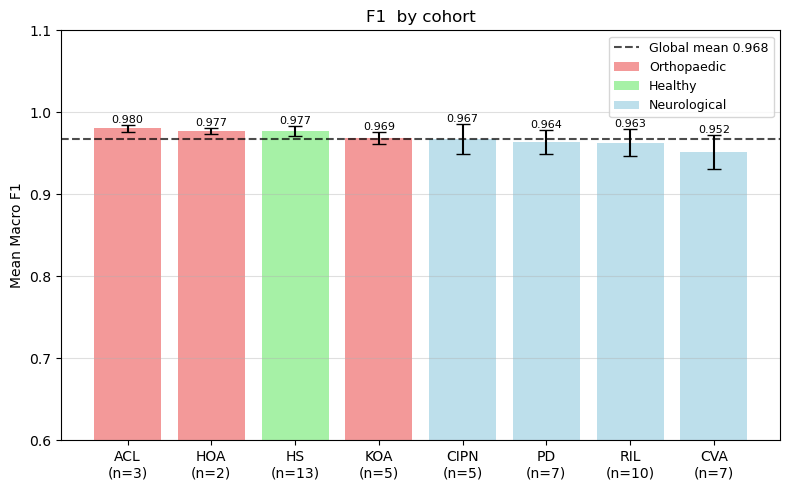

In [ ]:
diseases = []
for subj in df_test_f1['subject']:
  diseases.append(subj.split("_")[0])

df_test_f1['Disease'] = diseases

stats = plot_f1_by_cohort(df_test_f1, title="F1  by cohort")

# Result Comparison

In [ ]:
ckpt_path = '../checkpoints'
dir = Path(ckpt_path)

ckpt_dirs = [sub_dir.name for sub_dir in dir.iterdir() if sub_dir.is_dir()]

val_scores = []
test_scores = []
model_names = []

for name in ckpt_dirs:
    with open(Path(ckpt_path) / name / 'summary.json') as f:
        res = json.load(f)
    val_scores.append(res['val_f1'])
    test_scores.append(res['test_f1'])
    model_names.append(name[22:])

val_scores = np.array(val_scores)
test_scores = np.array(test_scores)

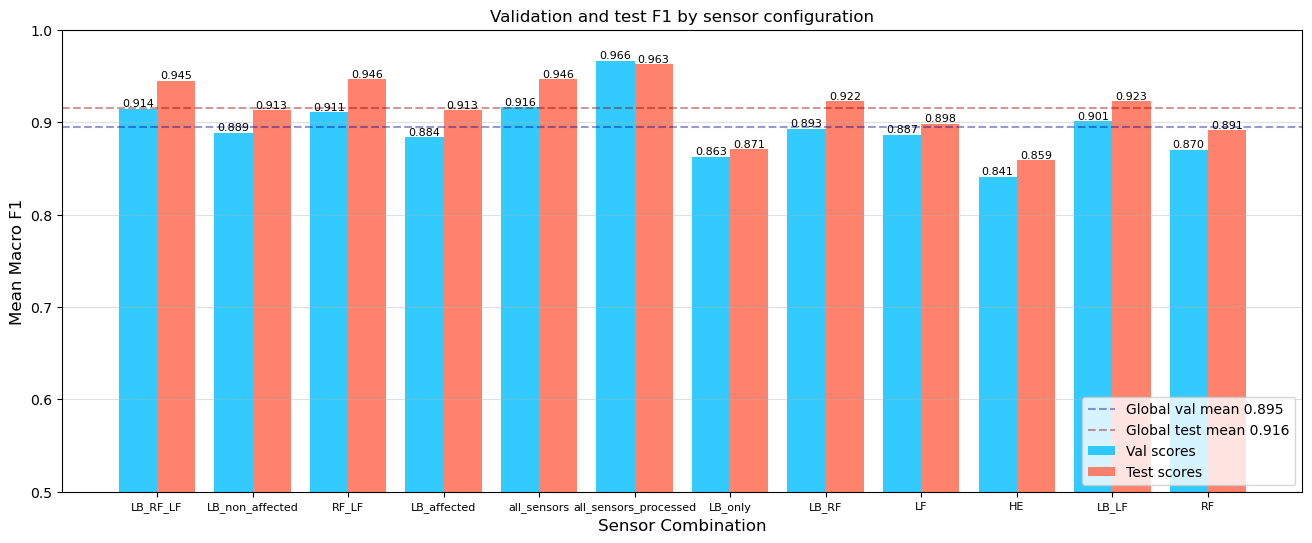

In [ ]:
plot_scores_by_sensor_conf(val_scores, test_scores, model_names)